# Create escape vecstor where binding =prod(1-escape ratio)


In [1]:
import matplotlib.pyplot as plt#5,7 best:.42, .47; pnas: 18,5
BEGIN=18
END=5
import os, sys
pgm_path = '../PGM/'

sys.path.append(pgm_path + 'source/')
sys.path.append(pgm_path + 'utilities/')
# sys.path.append('DNA_utils/')
# imports
import utilities, Proteins_utils, sequence_logo, plots_utils 

import rbm, RBM_utils

import random
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


e:\PATHS_NEW\covid\exp_data\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\PATHS_NEW\covid\exp_data\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights
C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:
import os 
os.listdir()

['ace2_kd_vector',
 'ACE2_training_seq.ipynb',
 'bloom_ab_classification',
 'desai',
 'escape vectors.ipynb',
 'fasta_files',
 'ic50_complete.csv',
 'normalized_Kd vectors.ipynb',
 'normalized_kd_vectors',
 'starr_nature',
 'starr_science',
 'voc_kd.ipynb',
 'wildtype_nucleotides.fasta',
 'wt_omicron.fasta',
 'wt_omicron_creation.ipynb']

In [3]:
df_bloom=pd.read_csv('starr_nature/starr_nature_all_antibodies_raw_data.csv', sep=',')
df_bloom=df_bloom[df_bloom['site']>=349] 
df_bloom=df_bloom[df_bloom['site']<=526]
#reset index

df_bloom

,condition,site,wildtype,mutation,mut_escape,site_total_escape,site_max_escape
186,LY-CoV016,349,S,N,0.016000,0.022500,0.016000
187,LY-CoV016,349,S,P,0.006499,0.022500,0.016000
188,LY-CoV016,351,Y,F,0.003909,0.005996,0.003909
189,LY-CoV016,351,Y,H,0.001044,0.005996,0.003909
190,LY-CoV016,351,Y,W,0.001044,0.005996,0.003909
...,...,...,...,...,...,...,...
56405,S309,526,G,P,0.038400,0.392600,0.044780
56406,S309,526,G,R,0.039280,0.392600,0.044780
56407,S309,526,G,S,0.037210,0.392600,0.044780
56408,S309,526,G,V,0.044280,0.392600,0.044780


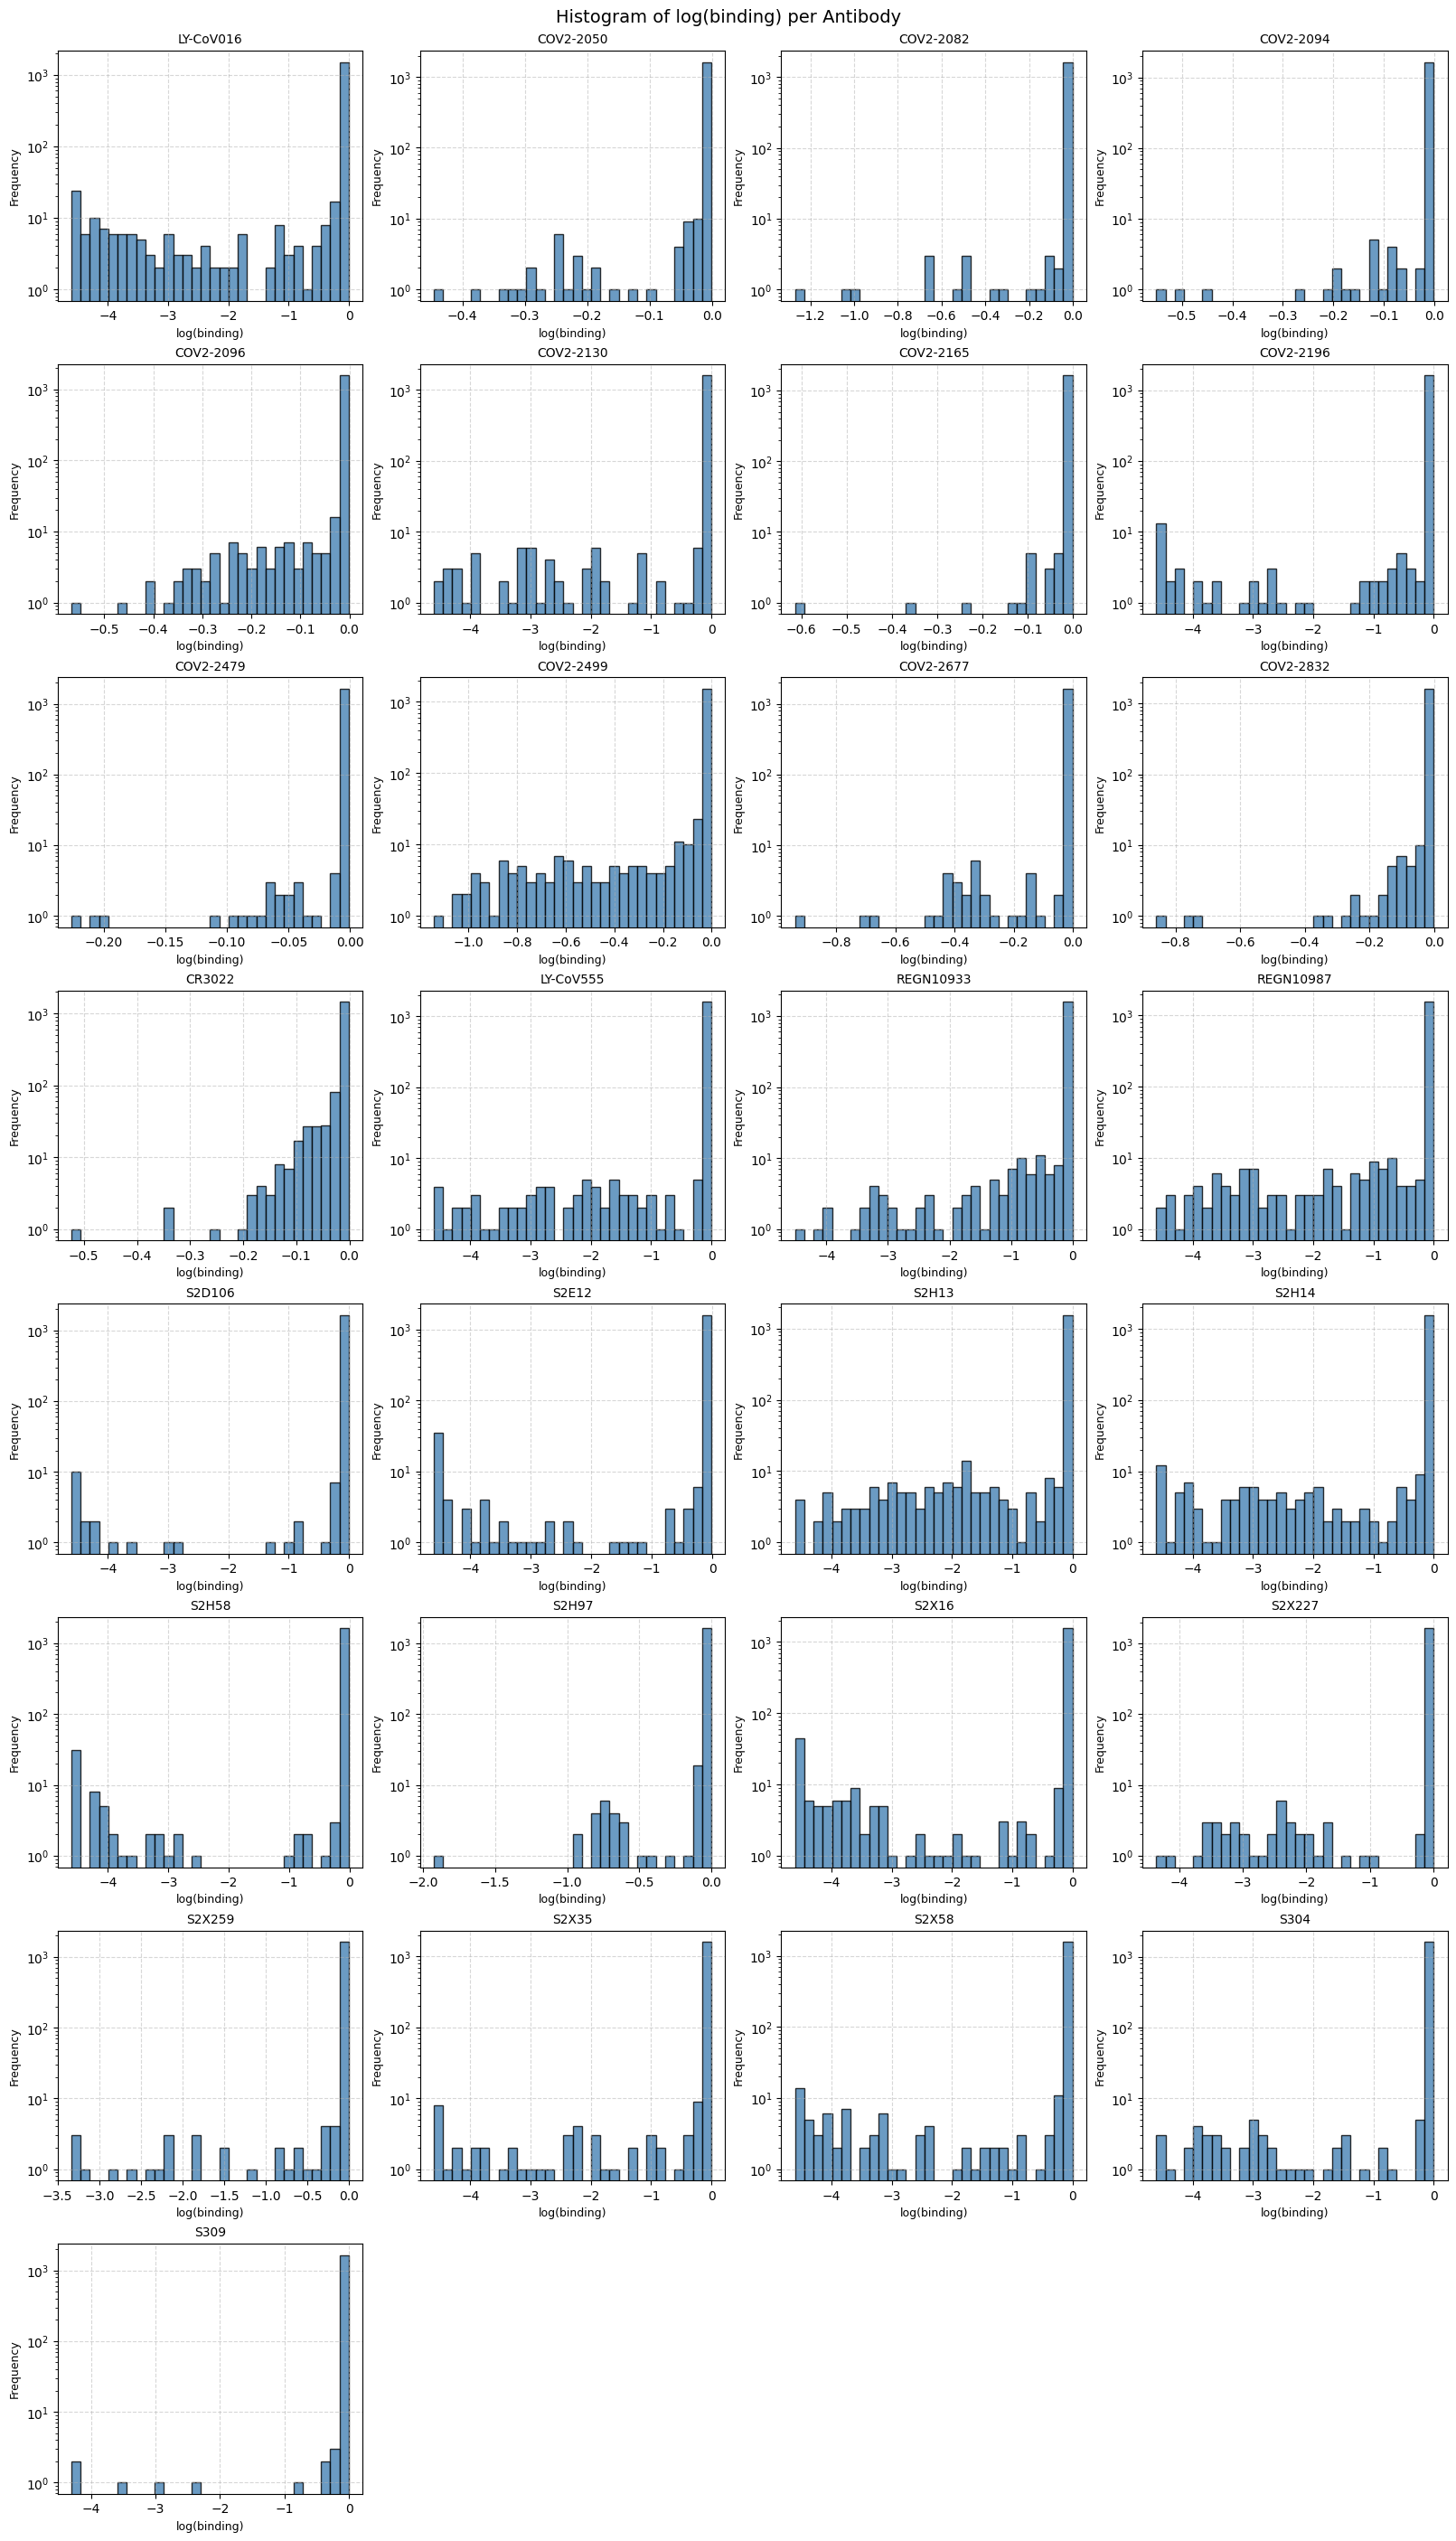

In [56]:
#put values < 0.01 to 0
df_bloom['mut_escape'] = np.where(df_bloom['mut_escape'] < 0.001, 0.001, df_bloom['mut_escape'])
#max value is 0.99
# df_bloom['mut_escape'] = np.where(df_bloom['mut_escape'] > 0.99, 0.99, df_bloom['mut_escape'])
#create binding=1-mut_escape
df_bloom['binding'] = 1 - df_bloom['mut_escape']
df_bloom['log_binding'] = np.log(df_bloom['binding'])

#plot histogram of log binding for each unique antibody
# Get unique antibodies
antibodies = df_bloom['condition'].unique()
n = len(antibodies)

# Determine subplot grid
cols = 4
rows = (n + cols - 1) // cols

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows), constrained_layout=True)
axes = axes.flatten()

# Plot histograms
for i, ab in enumerate(antibodies):
    ax = axes[i]
    ab_data = df_bloom[df_bloom['condition'] == ab]['log_binding']
    ax.hist(ab_data, bins=30, color='steelblue', alpha=0.8, edgecolor='black')
    ax.set_title(ab, fontsize=10)
    ax.set_xlabel('log(binding)', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_yscale('log')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Histogram of log(binding) per Antibody", fontsize=14)
plt.show()


In [57]:
df_bloom.columns

Index(['condition', 'site', 'wildtype', 'mutation', 'mut_escape',
       'site_total_escape', 'site_max_escape', 'binding', 'log_binding'],
      dtype='object')

In [58]:
#create a list containing the unique strings in condition column
conditions=df_bloom.condition.unique()
conditions

array(['LY-CoV016', 'COV2-2050', 'COV2-2082', 'COV2-2094', 'COV2-2096',
       'COV2-2130', 'COV2-2165', 'COV2-2196', 'COV2-2479', 'COV2-2499',
       'COV2-2677', 'COV2-2832', 'CR3022', 'LY-CoV555', 'REGN10933',
       'REGN10987', 'S2D106', 'S2E12', 'S2H13', 'S2H14', 'S2H58', 'S2H97',
       'S2X16', 'S2X227', 'S2X259', 'S2X35', 'S2X58', 'S304', 'S309'],
      dtype=object)

# Escape vectors

In [59]:
#df_bloom has following columns. 
#for every condition in df bloom, create an array of size (178, 20) full of zeros
# site starts at 349 and ends at 526. AMino acid encodings are  below
aa = [
    "A",
    "C",
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "K",
    "L",
    "M",
    "N",
    "P",
    "Q",
    "R",
    "S",
    "T",
    "V",
    "W",
    "Y",
    "-",
]

#add log_binding value of every row to the array at the index of the site and the amino acid
#put the array in 1D and save it
for condition in conditions:
    # Create a 2D array of zeros with shape (178, 20)
    q = np.ones((178, 20))*np.log(1-0.001)

    # Get the data for the current condition
    condition_data = df_bloom[df_bloom['condition'] == condition]

    # Iterate through each row in the condition data
    for index, row in condition_data.iterrows():
        site = row['site'] - 349  # Adjust for zero-based indexing
        aa_index = aa.index(row['mutation'])
        q[site, aa_index] = row['log_binding']

    #check absence of nan
    if np.isnan(q).any():
        print('nan in array')
        raise ValueError('nan in array')
    else:
        print('no nan in array')

    # Save the array to a file after reshaping it to 1D
    q = q.flatten()
    # Save the array to a file


    np.save('escape_vectors/'+condition+'delta_G.npy', q)
    print('escape_vectors/'+condition+'delta_G.npy')



no nan in array
escape_vectors/LY-CoV016delta_G.npy
no nan in array
escape_vectors/COV2-2050delta_G.npy
no nan in array
escape_vectors/COV2-2082delta_G.npy
no nan in array
escape_vectors/COV2-2094delta_G.npy
no nan in array
escape_vectors/COV2-2096delta_G.npy
no nan in array
escape_vectors/COV2-2130delta_G.npy
no nan in array
escape_vectors/COV2-2165delta_G.npy
no nan in array
escape_vectors/COV2-2196delta_G.npy
no nan in array
escape_vectors/COV2-2479delta_G.npy
no nan in array
escape_vectors/COV2-2499delta_G.npy
no nan in array
escape_vectors/COV2-2677delta_G.npy
no nan in array
escape_vectors/COV2-2832delta_G.npy
no nan in array
escape_vectors/CR3022delta_G.npy
no nan in array
escape_vectors/LY-CoV555delta_G.npy
no nan in array
escape_vectors/REGN10933delta_G.npy
no nan in array
escape_vectors/REGN10987delta_G.npy
no nan in array
escape_vectors/S2D106delta_G.npy
no nan in array
escape_vectors/S2E12delta_G.npy
no nan in array
escape_vectors/S2H13delta_G.npy
no nan in array
escape_vec

# Test in wildtype and BA1

In [60]:


WT_SEQ=Proteins_utils.load_FASTA('../exp_data/wt_omicron.fasta')[0]
#betwee 18 and 5
WT_SEQ=WT_SEQ[BEGIN:-END]

BA1=Proteins_utils.load_FASTA('../exp_data/wt_omicron.fasta')[1]

BA1=BA1[BEGIN:-END]


WT_SEQ

array([15, 17, 19,  0, 18, 11, 14,  8, 14,  7, 15, 11,  1, 17,  0,  2, 19,
       15, 17,  9, 19, 11, 15,  0, 15,  4, 15, 16,  4,  8,  1, 19,  5, 17,
       15, 12, 16,  8,  9, 11,  2,  9,  1,  4, 16, 11, 17, 19,  0,  2, 15,
        4, 17,  7, 14,  5,  2,  3, 17, 14, 13,  7,  0, 12,  5, 13, 16,  5,
        8,  7,  0,  2, 19, 11, 19,  8,  9, 12,  2,  2,  4, 16,  5,  1, 17,
        7,  0, 18, 11, 15, 11, 11,  9,  2, 15,  8, 17,  5,  5, 11, 19, 11,
       19,  9, 19, 14,  9,  4, 14,  8, 15, 11,  9,  8, 12,  4,  3, 14,  2,
        7, 15, 16,  3,  7, 19, 13,  0,  5, 15, 16, 12,  1, 11,  5, 17,  3,
        5,  4, 11,  1, 19,  4, 12,  9, 13, 15, 19,  5,  4, 13, 12, 16, 11,
        5, 17,  5, 19, 13, 12, 19, 14, 17, 17, 17,  9, 15,  4,  3,  9,  9,
        6,  0, 12,  0, 16, 17,  1,  5], dtype=int16)

In [61]:


import torch

def one_hot_encode_concat(s):
    # Number of categories for one-hot encoding, 21 for values 0 through 20
    num_categories = 20
    # Create a tensor of zeros with shape [len(s), num_categories]
    one_hot_matrix = np.zeros((len(s), num_categories))

    # Use  indexing to set the appropriate elements to 1
    for i, char in enumerate(s):
    
        one_hot_matrix[i, char] = 1
    # Convert to 1D
    one_hot_encoded = one_hot_matrix.flatten()

    return one_hot_encoded
    
ONE_HOT_WT=np.array(WT_SEQ)
ONE_HOT_WT=one_hot_encode_concat(ONE_HOT_WT)

ONE_HOT_BA1=np.array(BA1)
ONE_HOT_BA1=one_hot_encode_concat(ONE_HOT_BA1)
print(ONE_HOT_BA1.shape)
print(ONE_HOT_WT.shape)


(3560,)
(3560,)


In [62]:
def get_log_binding(s,escape_vector):
    return np.dot(s, escape_vector)

escape_lycov=np.load('escape_vectors/LY-CoV555delta_G.npy')
escape_S2E12=np.load('escape_vectors/S2E12delta_G.npy')

print(escape_lycov.shape)
print(escape_S2E12.shape)
print('WT')
# Get the log binding values for the WT sequence
log_binding_WT_lycov = get_log_binding(ONE_HOT_WT, escape_lycov)
log_binding_WT_S2E12 = get_log_binding(ONE_HOT_WT, escape_S2E12)

print(log_binding_WT_lycov)
print(log_binding_WT_S2E12)

print('BA1')
# Get the log binding values for the BA1 sequence
log_binding_BA1_lycov = get_log_binding(ONE_HOT_BA1, escape_lycov)
log_binding_BA1_S2E12 = get_log_binding(ONE_HOT_BA1, escape_S2E12)

print(log_binding_BA1_lycov)
print(log_binding_BA1_S2E12)

(3560,)
(3560,)
WT
-0.17808905937786906
-0.17808905937786906
BA1
-5.9374318518914535
-0.8610974174586945
